<a href="https://colab.research.google.com/github/Rithvikns/python/blob/main/Framework/Pytorch/project_1/Image_proccesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
from google.colab import files

In [2]:
uploaded = files.upload()
image_filename = list(uploaded.keys())[0]  # Get uploaded file name

# Step 2: Load the Image and Display It
image = Image.open(image_filename).convert("RGB")  # Open as RGB


Saving download.jpeg to download.jpeg


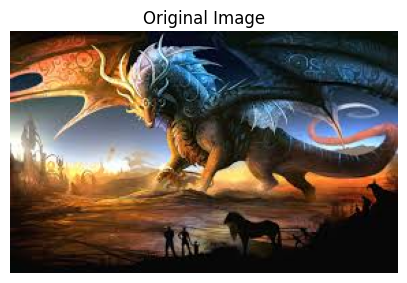

In [3]:
# Display Original Image
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to ResNet-50 expected input
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])


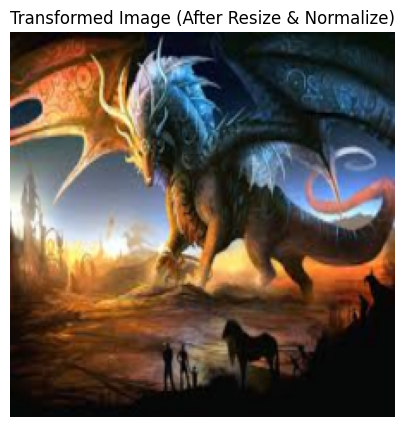

In [5]:
image_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Step 4: Display the Transformed Image (Denormalized)
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = tensor.squeeze(0).numpy().transpose(1, 2, 0)  # Remove batch dim & convert to (H,W,C)
    img = (img * std) + mean  # De-normalize
    img = np.clip(img, 0, 1)  # Clip values to valid range
    return img
plt.figure(figsize=(5,5))
plt.imshow(denormalize(image_tensor))
plt.axis("off")
plt.title("Transformed Image (After Resize & Normalize)")
plt.show()

In [6]:
# Step 5: Load Pretrained ResNet-50 Model
model = models.resnet50(pretrained=True)
model.eval()  # Set model to evaluation mode

# Step 6: Extract Features from an Intermediate Layer (Conv Layer)
layer_name = "layer1"  # Change to "layer2", "layer3" for deeper layers
activation = {}


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 94.0MB/s]


In [7]:
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

model.layer1.register_forward_hook(get_activation(layer_name))

# Run Forward Pass
with torch.no_grad():
    _ = model(image_tensor)


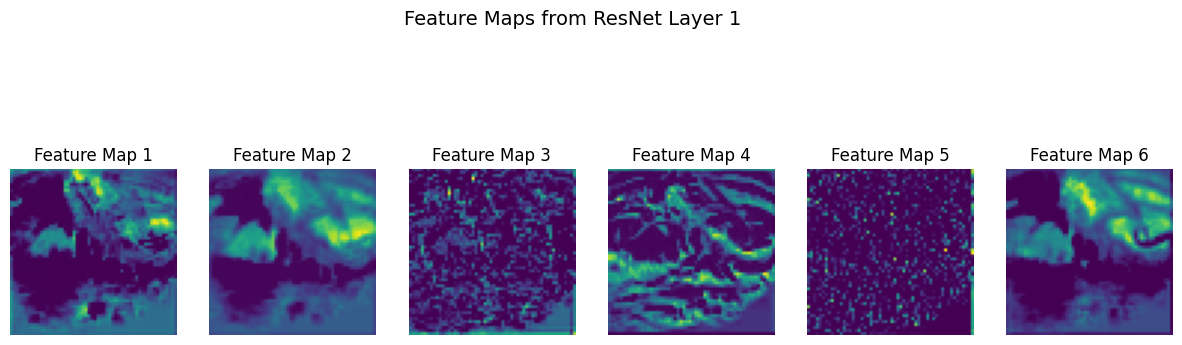

In [8]:
# Step 7: Visualize Feature Maps from ResNet’s Layer 1
feature_maps = activation[layer_name].squeeze(0)  # Remove batch dimension

num_features = 6  # Show first 6 feature maps
fig, axes = plt.subplots(1, num_features, figsize=(15,5))

for i in range(num_features):
    ax = axes[i]
    feature_map = feature_maps[i].cpu().numpy()
    ax.imshow(feature_map, cmap="viridis")  # Use a color map for better visualization
    ax.axis("off")
    ax.set_title(f"Feature Map {i+1}")

plt.suptitle("Feature Maps from ResNet Layer 1", fontsize=14)
plt.show()